# Test Landmarks

In [1]:
import tensorflow as tf
import tensorflow_io as tfio

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed

import mediapipe as mp
from itertools import combinations

2023-05-04 12:07:08.377465: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-04 12:07:08.427568: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-05-04 12:07:09.243726: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
TESTING_COHERENCE_LOSS = "l1"
TESTING_MAIN_LOSS = "l1"

# Dimensions
BATCH_SIZE = 20
IMG_WIDTH = 64
IMG_HEIGHT = 64
N_CHANNELS = 3


STEPS = 100000

LAMBDA1 = 1000
LAMBDA2 = 200

VIDEOS_FOLDER = 'mug_preprocessed'

In [3]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [4]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    if n_frames > 20:
        plot_sequence = plot_sequence[:20]
        n_frames = 20
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im) 
        ax.axis('off')
    plt.show()
    plt.close()

def plot_frame(frame, title=None):
    plt.imshow(frame)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()
    plt.close()

def plot_normalized_frame(frame, title=None):
    plot_frame(normalized_sequence_to_images(frame), title)

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

In [5]:
videos_path = list(Path(f'../data/{VIDEOS_FOLDER}/').glob('**/*.npy'))

In [6]:
DATASET_SIZE = len(videos_path)
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_paths = videos_path[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_paths = videos_path[train_size:]

print(len(train_paths))
print(len(test_paths))

722
310


In [7]:
class FrameDataGenerator():
    
    def __init__(self, videos_path, batch_size=1):
        self.videos_path = videos_path
        self.n = len(videos_path)
        self._restart()
        self.batch_size = batch_size
    
    def _load_current_video(self):
        self.current_video = np.load(self.videos_path[self.current_video_index])
        # print(f"Loading video {self.current_video_index+1} of {self.n} with {self.current_video.shape[0]} frames")
    
    def __iter__(self):
        return self
    
    def _load_next_video(self):
        self.current_frame_index = 1
        self.current_video_index += 1
        self._load_current_video()
    
    def _restart(self):
        self.current_video_index = 0
        self.current_frame_index = 0
        self._load_current_video()
    

    def _current_frame(self):
        return self.current_video[self.current_frame_index]
    
    def _next_frame(self):
        return self.current_video[self.current_frame_index+1]
    
    def _previous_frame(self):
        return self.current_video[self.current_frame_index-1]
    
    def _current_video_has_next_frame(self):
        return self.current_frame_index+1 < self.current_video.shape[0]
    
    def _has_current_video(self):
        return self.current_video_index < self.n
    
    def _has_next_video(self):
        return self.current_video_index+1 < self.n
    
    def _end_of_videos(self):
            raise StopIteration
    
    def _get_current_frames(self):
        return self._previous_frame(), self._current_frame(), self._next_frame()
    
    def _get_batch(self):
        batch_previous_frame = []
        batch_current_frame = []
        batch_next_frame = []
        for i in range(self.batch_size):
            previous_frame, current_frame, next_frame = self._get_current_frames()
            batch_previous_frame.append(previous_frame)
            batch_current_frame.append(current_frame)
            batch_next_frame.append(next_frame)
        return np.array(batch_previous_frame), np.array(batch_current_frame), np.array(batch_next_frame)


    def __next__(self):
        self.current_frame_index += 1 # Frame index start at one because we have to return the previous frame
        if not self._has_current_video():
            self._end_of_videos()
        while not self._current_video_has_next_frame():
            if self._has_next_video():
                self._load_next_video()
            else:
                self._end_of_videos()
        return self._get_batch()
    
    def __call__(self):
        return next(self)
    
    def take(self, n):
        for i in range(n):
            try:
                yield self()
            except StopIteration:
                self._restart()
    
    def __iter__(self):
        return self
    
    def repeat(self):
        while True:
            try:
                yield self()
            except StopIteration:
                self._restart()

In [8]:
train_generator = FrameDataGenerator(train_paths, batch_size=20)
test_generator = FrameDataGenerator(test_paths, batch_size=20)

previous_frame, current_frame, next_frame = next(test_generator)
print(previous_frame.shape)
print(current_frame.shape)
print(next_frame.shape)

(20, 64, 64, 3)
(20, 64, 64, 3)
(20, 64, 64, 3)


In [9]:
# Grabbing the Holistic Model from Mediapipe and
# Initializing the Model
mp_holistic = mp.solutions.holistic
holistic_model = mp_holistic.Holistic(
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)
 
# Initializing the drawing utils for drawing the facial landmarks on image
mp_drawing = mp.solutions.drawing_utils

(64, 64, 3)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
2023-05-04 12:07:12.494723: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13917 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)
(64, 64, 3)


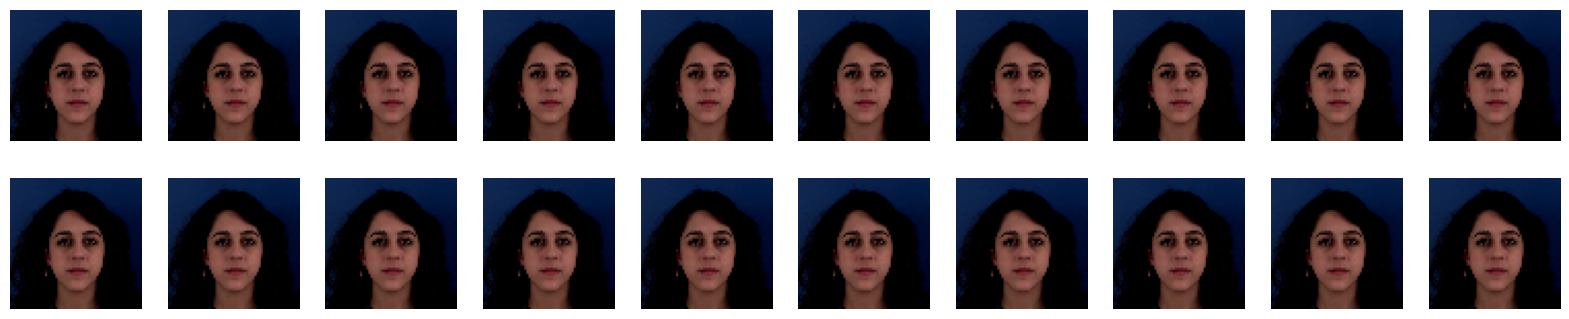

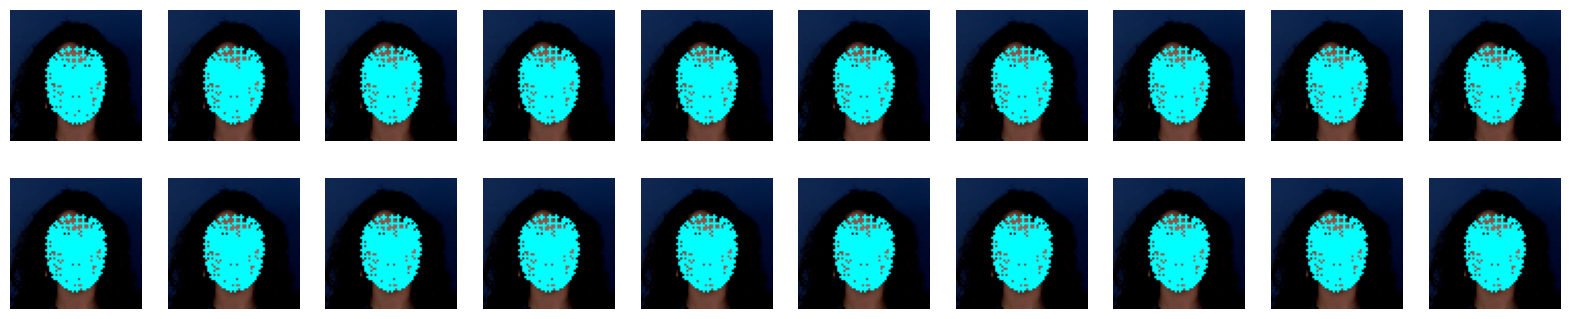

In [10]:

out_frames = []
out_landmarks = []

for image in current_frame:
    
    tf.print(image.shape)
    image =  normalized_sequence_to_images(image)
    image = np.array(image, dtype=np.uint8)

    results = holistic_model.process(image)
 
    # Drawing the Facial Landmarks
    # mp_drawing.draw_landmarks(
    #   image,
    #   results.face_landmarks,
    #   mp_holistic.FACEMESH_CONTOURS,
    #   mp_drawing.DrawingSpec(
    #     color=(255,0,255),
    #     thickness=1,
    #     circle_radius=1
    #   ),
    #   mp_drawing.DrawingSpec(
    #     color=(0,255,255),
    #     thickness=1,
    #     circle_radius=1
    #   )
    # )
    # draw facial landmarks with opencv
    landmarks = results.face_landmarks.landmark
    for l in landmarks:
        cv2.circle(image, (int(l.x*image.shape[1]), int(l.y*image.shape[0])), 1, (0, 255, 255), -1)

    out_landmarks.append(landmarks)
     
    out_frames.append(image)
 
out_frames = np.array(out_frames)

plot_normalized_sequence(current_frame)
plot_sequence(out_frames)

In [11]:
clip_landmarks = np.array(out_landmarks)
for frame_landmarks in clip_landmarks:
    for current_landmarks in frame_landmarks:
        x, y, z = current_landmarks.x, current_landmarks.y, current_landmarks.z
        print("X: ", x, "Y: ", y, "Z: ", z)
        print()

X:  0.5096725821495056 Y:  0.6826881170272827 Z:  -0.05977878347039223

X:  0.510834813117981 Y:  0.6040898561477661 Z:  -0.09968481212854385

X:  0.5098093748092651 Y:  0.6294767260551453 Z:  -0.054956916719675064

X:  0.4936659038066864 Y:  0.538816511631012 Z:  -0.07143032550811768

X:  0.5107955932617188 Y:  0.5823469161987305 Z:  -0.10492534190416336

X:  0.5103002190589905 Y:  0.5558253526687622 Z:  -0.0961700901389122

X:  0.507985532283783 Y:  0.4930398464202881 Z:  -0.04094960168004036

X:  0.3732750117778778 Y:  0.49597856402397156 Z:  0.027844294905662537

X:  0.5071280002593994 Y:  0.44026821851730347 Z:  -0.024794936180114746

X:  0.5071742534637451 Y:  0.4108961224555969 Z:  -0.026447176933288574

X:  0.5056836605072021 Y:  0.3091060221195221 Z:  0.0008892370969988406

X:  0.5096032619476318 Y:  0.6938396692276001 Z:  -0.05754099041223526

X:  0.5093654990196228 Y:  0.70241379737854 Z:  -0.051483362913131714

X:  0.5090916752815247 Y:  0.7061686515808105 Z:  -0.0434130057

In [12]:
def landmarks_to_array(landmarks):
    x = []
    y = []
    z = []
    for current_landmarks in landmarks:
        x.append(current_landmarks.x)
        y.append(current_landmarks.y)
        z.append(current_landmarks.z)
    return np.array([x, y, z])

def get_landmarks(clip):
    clip_landmarks = []
    for frame in clip:
        frame =  normalized_sequence_to_images(frame)
        results = holistic_model.process(frame)
        landmarks_array = landmarks_to_array(results.face_landmarks.landmark)
        out_landmarks.append(results.face_landmarks.landmark)
        clip_landmarks.append(landmarks_array)
    return np.array(clip_landmarks)

# apply the function to all the frames
array_landmarks = np.array([get_landmarks(frame_landmarks) for frame_landmarks in out_landmarks])
array_landmarks = np.moveaxis(array_landmarks, 1, 2)
print(array_landmarks.shape)

TypeError: Could not generate a generic TraceType for x: 0.5096725821495056
y: 0.6826881170272827
z: -0.05977878347039223
.Please verify that it is immutable/hashable. Otheriwse, consider implementing the Tracing Protocol for it.

In [ ]:
@tf.function
def l1_loss(previous, current):
  return  tf.math.abs(current-previous)

@tf.function
def get_luminance(image):
  output = normalized_sequence_to_images(image)
  output = tfio.experimental.color.rgb_to_ycbcr(output)
  output = output[...,0] # get y from ycbcr
  return tf.cast(output, tf.float32)

@tf.function
def apply_luminance_loss(previous, current, loss_function):
  previous_luminance = get_luminance(previous)
  current_luminance = get_luminance(current)
  return loss_function(previous_luminance, current_luminance)
  

@tf.function
def mean_loss(y_true, y_pred, loss_function):
  y_true = tf.cast(y_true, tf.float32)
  y_pred = tf.cast(y_pred, tf.float32)
  return tf.math.reduce_mean(loss_function(y_true, y_pred))

@tf.function
def coherence_mean_loss(previous_y_true, y_true, previous_y_pred, y_pred, loss_function):
  loss_true = apply_luminance_loss(previous_y_true, y_true, loss_function)
  loss_pred = apply_luminance_loss(previous_y_pred, y_pred, loss_function)
  return tf.math.reduce_mean(tf.abs(loss_true - loss_pred))


@tf.function
def all_pairs_distances(x):
  indices = np.array(list(combinations(range(len(array_landmarks[0])), 2)))
  return tf.math.reduce_mean([tf.math.abs(x[a]-x[b]) for  a, b in tqdm(indices)])


@tf.function
def landmarks_coherence_loss(previous_y_true, y_true, previous_y_pred, y_pred, loss_function):
  loss_true = apply_luminance_loss(previous_y_true, y_true, loss_function)
  loss_pred = apply_luminance_loss(previous_y_pred, y_pred, loss_function)
  return tf.abs(loss_true - loss_pred)



@tf.function
def coherence_landmarks_loss(previous_y_true, y_true, previous_y_pred, y_pred, loss_function):
  loss_true = loss_function(previous_y_true, y_true)
  loss_pred = loss_function(previous_y_pred, y_pred)
  return tf.math.reduce_mean(tf.abs(loss_true - loss_pred))

In [ ]:
print(coherence_mean_loss(array_landmarks[0], array_landmarks[1], array_landmarks[10], array_landmarks[11], l1_loss))


tf.Tensor(0.13034189, shape=(), dtype=float32)


In [ ]:
all_pairs_distances(array_landmarks[0])

  0%|          | 0/109278 [00:00<?, ?it/s]

<tf.Tensor: shape=(), dtype=float64, numpy=0.10670783712172115>

In [ ]:
def cartesian_graph(a):
    """
    Given at least 2 elements in a, generates the Cartesian product of all
    elements in the list.
    """
    tile_a = tf.expand_dims(tf.tile(tf.expand_dims(a[0], 1), [1, tf.shape(a[1])[0]]), 2)
    tile_b = tf.expand_dims(tf.tile(tf.expand_dims(a[1], 0), [tf.shape(a[0])[0], 1]), 2)
    cart = tf.concat([tile_a, tile_b], axis=2)
    cart = tf.reshape(cart, [-1, 2])
    for c in a[2:]:
        tile_c = tf.tile(tf.expand_dims(c, 1), [1, tf.shape(cart)[0]])
        tile_c = tf.expand_dims(tile_c, 2)
        tile_c = tf.reshape(tile_c, [-1, 1])
        cart = tf.tile(cart, [tf.shape(c)[0], 1])
        cart = tf.concat([tile_c, cart], axis=1)
    return cart

def permutations(a, times=2):
    """
    Shortcut for generating the Cartesian product of self, using indices so
    that we can work with a small number of elements initially.
    """
    options = tf.range(tf.shape(a)[0])
    indices = cartesian_graph([options for _ in range(times)])
    return tf.gather(a, indices)

# Get all length 4 permutations of the 3-element vector
options = tf.constant([0, 1, 2])
cart = permutations(array_landmarks[0], times=2)

print(cart.shape) 

(219024, 2, 3)
